Tutorial 3 code. Assignment 1 - Quasars part 2

In [50]:
#import the packages
import numpy as np
import scipy as scp
import scipy.stats as stats
import matplotlib.pyplot as plt
import math

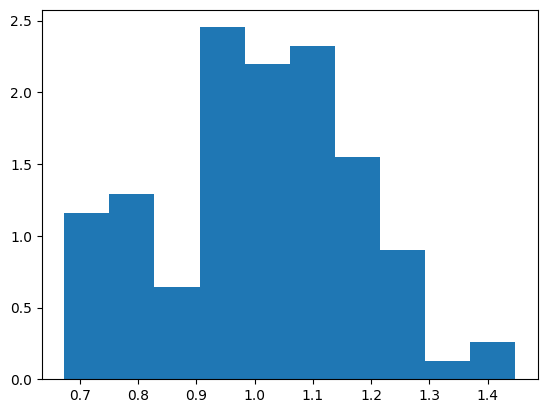

In [52]:
#let's generate the underlying dataset with the given true parameters
mean = 1
std_div = 0.2
N = 100
#here we generate the dataset
dataset = np.random.normal(mean,std_div,N)
#here is the distribution, it is obviously gaussian centered around 1
plt.hist(dataset, density=True)
plt.show()
#now let's compute the total log likelihood as function of the mu parameter

<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Cyber\AppData\Local\Temp\ipykernel_29100\1635260080.py:10: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$\mu$")


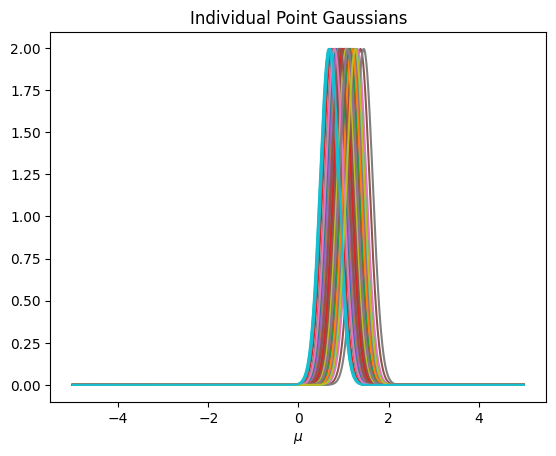

In [90]:
#now let's plot each likelihood individually
#axes, fig = plt.subplots(figsize=(7,7))
x_grid = np.linspace(-5,5,1000)

for point in dataset: 
    gaussian = stats.norm(point,std_div)
    y_dist = gaussian.pdf(x_grid)
    plt.plot(x_grid, y_dist)
plt.title("Individual Point Gaussians")
plt.xlabel("$\mu$")
plt.show()

C:\Users\Cyber\AppData\Local\Temp\ipykernel_29100\1039669901.py:9: RuntimeWarning: divide by zero encountered in log
  plt.plot(x_grid, np.log(y_likelihood))


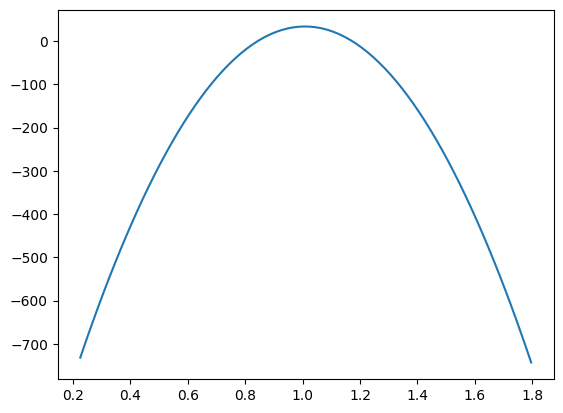

The Numerical MLE is:1.0060060060060056
The Analytic MLE is:1.008139930262211


C:\Users\Cyber\AppData\Local\Temp\ipykernel_29100\1039669901.py:12: RuntimeWarning: divide by zero encountered in log
  log_likelihood = np.log(y_likelihood)


In [ ]:
#now we need to plot the combined likelihood(just multiply out the individual likelihoods)
y_likelihood = np.ones(len(x_grid))
for point in dataset:
    gaussian = stats.norm(point,std_div)
    y_dist = gaussian.pdf(x_grid)
    y_likelihood *= y_dist
#plot the log-likelihood function for the data
plt.plot(x_grid, np.log(y_likelihood))
plt.show()
#now let's get the maximum likelihood estimator graphically
log_likelihood = np.log(y_likelihood)
max_likelihood_num = x_grid[np.argmax(y_likelihood)]
analytic_mle = np.mean(dataset)
print(f"The Numerical MLE is:{max_likelihood_num}")
print(f"The Analytic MLE is:{analytic_mle}")

In [94]:
#now, let's compute the fisher matrix element(the matrix is 1D here)
delta_mu = x_grid[5]-x_grid[4]
second_derivative = np.diff(log_likelihood, 2)/delta_mu**2
error = (-second_derivative[np.argmax(y_likelihood)])**(-0.5)
analytic_error = std_div/(np.sqrt(N))
print(f"Numerical error: {error}")
print(f"Analytic error: {analytic_error}")
#it can be seen that two values are remarkably close

Numerical error: 0.02000000000000015
Analytic error: 0.02


C:\Users\Cyber\AppData\Local\Temp\ipykernel_29100\390331708.py:12: RuntimeWarning: divide by zero encountered in log
  plt.plot(x_grid, np.log(y_likelihood))


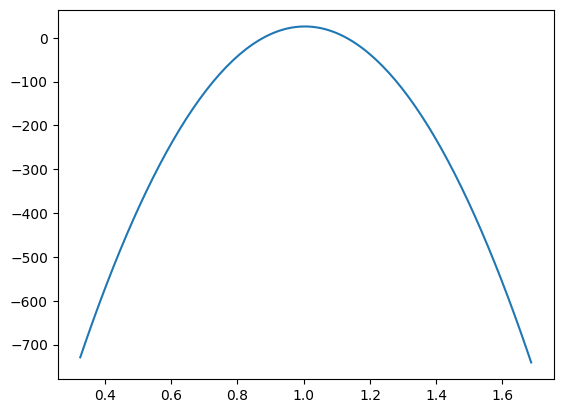

The Numerical MLE is:1.0060060060060056
The Analytic MLE is:1.008139930262211
Numerical error: 0.01744926910395289
Analytic error: 0.017449269103952607


C:\Users\Cyber\AppData\Local\Temp\ipykernel_29100\390331708.py:15: RuntimeWarning: divide by zero encountered in log
  log_likelihood = np.log(y_likelihood)


In [104]:
#finally we may repeat this for a Heteoscedastic measurement set

meas_error_set = np.random.normal(std_div, 0.05, N)
hetero_dataset = np.random.normal(mean, meas_error_set, N)
#compute the log_likelihood of the dataset:
y_likelihood = np.ones(len(x_grid))
for i,point in enumerate(dataset):
    gaussian = stats.norm(point,meas_error_set[i])
    y_dist = gaussian.pdf(x_grid)
    y_likelihood *= y_dist
#plot the log-likelihood function for the data
plt.plot(x_grid, np.log(y_likelihood))
plt.show()
#now let's get the maximum likelihood estimator graphically
log_likelihood = np.log(y_likelihood)
max_likelihood_num = x_grid[np.argmax(y_likelihood)]
analytic_mle = np.mean(dataset)
print(f"The Numerical MLE is:{max_likelihood_num}")
print(f"The Analytic MLE is:{analytic_mle}")

second_derivative = np.diff(log_likelihood, 2)/delta_mu**2
error = (-second_derivative[np.argmax(y_likelihood)])**(-0.5)
analytic_error = np.sum(1/meas_error_set**2)**(-0.5)
print(f"Numerical error: {error}")
print(f"Analytic error: {analytic_error}")
